In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp

In [2]:
depot = 0
schools = [1, 2]

C:\Users\diego\AppData\Local\Temp\ipykernel_51204\4103280198.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


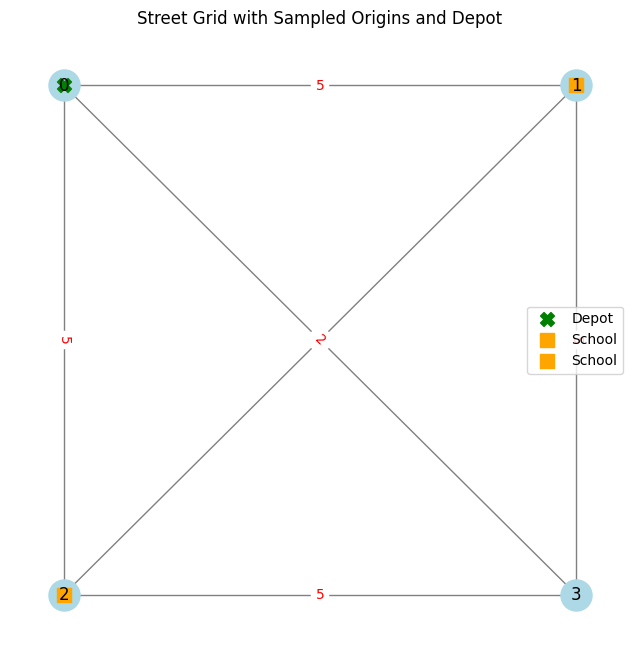

In [3]:
g = nx.Graph()
node_mapping = {}  # Map (row, col) to a unique integer
counter = 0

for i in range(2):
    for j in range(2):
        node_mapping[(i, j)] = counter
        counter += 1

for i in range(2):
    for j in range(2):
        if i > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i - 1, j)], weight=5)
        if j > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i, j - 1)], weight=5)

g.add_edge(node_mapping[(0, 0)], node_mapping[(1, 1)], weight=2)  # Diagonal edge with different weight
g.add_edge(node_mapping[(0, 1)], node_mapping[(1, 0)], weight=2)  # Another diagonal edge with different weight

# Add length attribute to edges
for u, v in g.edges():
    g.edges[u, v]['length'] = 1

# Generate positions for nodes (2D grid layout)
pos = {node_mapping[(x, y)]: (y, -x) for x, y in node_mapping.keys()}

# Randomly sample 20 points in the 2D space [min(p[0]), max(p[0])] x [min(p[1]), max(p[1])] for p in pos.values()
origins = []

g.nodes[2]['demand'] = 5
# in the future, make mapping using dict
student_mapping = {(2,schools[0]): 5}

# Visualize the graph and sampled points
fig, ax = plt.subplots(figsize=(8,8))
# label edges with weights
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in g.edges(data=True)}
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color='red', ax=ax)

# Plot the depot and schools
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X', zorder=2)
for school in schools:
    ax.scatter(pos[school][0], pos[school][1], color='orange', s=100, label='School', marker='s', zorder=2)

ax.legend()
ax.set_title('Street Grid with Sampled Origins and Depot')
fig.show()

In [4]:
arcs = []
weights = []

for u, v, data in g.edges(data=True):
    w = data['weight']
    arcs.append((u, v))
    weights.append(w)
    arcs.append((v, u))
    weights.append(w)

A = len(arcs)

# x[a] = 1 if arc a is used
x = cp.Variable(A, boolean=True)
# single commodity flow variable
f = cp.Variable(A, nonneg=True)

objective = cp.Minimize(cp.sum(cp.multiply(weights, x)))
constraints = []

# degree constraints
for v in g.nodes():
    in_idx = [i for i, (_, w) in enumerate(arcs) if w == v]
    out_idx = [i for i, (u, _) in enumerate(arcs) if u == v]

    in_flow = cp.sum(cp.hstack([x[i] for i in in_idx])) if in_idx else 0
    out_flow = cp.sum(cp.hstack([x[i] for i in out_idx])) if out_idx else 0

    if v == depot:
        # start node: one outgoing, at most one incoming
        constraints.append(out_flow == 1)
        constraints.append(in_flow <= 1)
    elif v in schools:
        # each school must be visited exactly once
        constraints.append(in_flow == 1)
        constraints.append(out_flow == 1)
    else:
        # intermediate nodes: in-degree = out-degree (if used)
        constraints.append(in_flow == out_flow)

# flow constraints
demand = {v: 0 for v in g.nodes()}
demand[depot] = -len(schools)  # depot supplies |schools| units
for s in schools:
    demand[s] = 1

for v in g.nodes():
    in_idx = [i for i, (_, w) in enumerate(arcs) if w == v]
    out_idx = [i for i, (u, _) in enumerate(arcs) if u == v]

    in_f = cp.sum(cp.hstack([f[i] for i in in_idx])) if in_idx else 0
    out_f = cp.sum(cp.hstack([f[i] for i in out_idx])) if out_idx else 0

    # flow conservation: sum_out f - sum_in f = demand(v)
    constraints.append(out_f - in_f == demand[v])

# capacity linking
M = len(schools)  # maximum flow on any arc
for i in range(A):
    constraints.append(f[i] <= M * x[i])

In [5]:
prob = cp.Problem(objective, constraints)
print("Solving MILP")
try:
    # Try with verbose to see progress; set a reasonable time limit
    prob.solve(solver=cp.GLPK_MI, verbose=True, glpk={'msg_lev': 'GLP_MSG_ON', 'tm_lim': 2*60*1000})  # 2-min limit
except Exception as e:
    print(f"⚠️  GLPK_MI failed or unavailable: {e}")
    print("Trying CBC as fallback...")
    try:
        prob.solve(solver=cp.CBC, verbose=True, maximumSeconds=120)
    except Exception as e2:
        print(f"⚠️  CBC also failed: {e2}")
        print("Trying default solver...")
        prob.solve(verbose=True)

print()
print("Status:", prob.status)
print("Objective (total distance):", prob.value)

(CVXPY) Feb 25 11:25:47 PM: Your problem has 24 variables, 23 constraints, and 0 parameters.
(CVXPY) Feb 25 11:25:47 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 25 11:25:47 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 25 11:25:47 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.


(CVXPY) Feb 25 11:25:47 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 25 11:25:47 PM: Compiling problem (target solver=GLPK_MI).
(CVXPY) Feb 25 11:25:47 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GLPK_MI
(CVXPY) Feb 25 11:25:47 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 25 11:25:48 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 25 11:25:48 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 25 11:25:48 PM: Applying reduction GLPK_MI
(CVXPY) Feb 25 11:25:48 PM: Finished problem compilation (took 9.891e-02 seconds).
(CVXPY) Feb 25 11:25:48 PM: Invoking solver GLPK_MI  to obtain a solution.
(CVXPY) Feb 25 11:25:48 PM: Problem status: optimal
(CVXPY) Feb 25 11:25:48 PM: Optimal value: 1.200e+01
(CVXPY) Feb 25 11:25:48 PM: Compilation took 9.891e-02 seconds
(CVXPY) Feb 25 11:25:48 PM: Solver (including time spent in interface) took 4.982e-03 seconds


Solving MILP
                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

Status: optimal
Objective (total distance): 12.0


In [6]:
# Extract and print the route
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    print(f"⚠️ Solver did not find a feasible solution (status={prob.status}).")
else:
    print("Selected arcs in the route:")
    selected_arcs = [arc for i, arc in enumerate(arcs) if x.value[i] > 0.5]
    for arc in selected_arcs:
        i, j = arc
        print(f"Arc ({i}, {j}) with weight {g.edges[i, j]['weight']}")

Selected arcs in the route:
Arc (1, 0) with weight 5
Arc (2, 1) with weight 2
Arc (0, 2) with weight 5


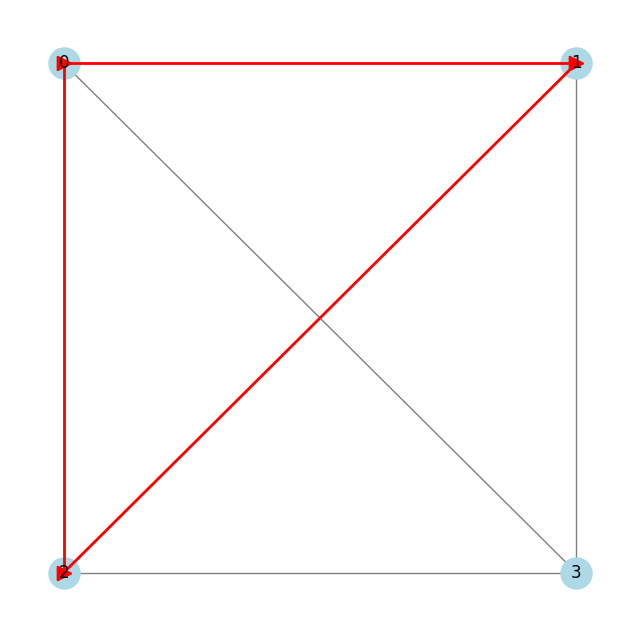

In [7]:
# Plot routes chosen by the solver
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X')
for arc in selected_arcs: 
    i, j = arc
    if x[arcs.index(arc)].value is not None and x[arcs.index(arc)].value > 0.5:  # Assuming binary variables
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color='red', linewidth=2, marker=">", markersize=10)